# Clustering audio à partir des fichiers chroma

On utilise ici la technique proposée dans l'article suivant : "USING CHROMA HISTOGRAM TO MEASURE THE PERCEPTUAL SIMILARITY OF
MUSIC", disponible à l'adresse https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=4607685.
Cette version nettoie ce qui a été fait dans l'optique de renvoyer une liste de centroïdes par compositeur.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.express as px
from plotly.offline import plot
import plotly.io as pio
from sklearn.manifold import MDS
import librosa
from scipy.cluster.hierarchy import linkage, dendrogram
import os
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
def verbose(message, verbose_level, verbose_threshold=0):
    if verbose_level > verbose_threshold:
        print(message)

In [3]:
li_filenames = []

for racine, _, fichiers in os.walk('cross-composer'):
    for fichier in fichiers:
        chemin_relatif = os.path.relpath(os.path.join(racine, fichier))
        li_filenames.append(chemin_relatif)

In [4]:
li_filenames

['cross-composer\\chroma-nnls_01_bach.csv',
 'cross-composer\\chroma-nnls_02_beethoven.csv',
 'cross-composer\\chroma-nnls_03_brahms.csv',
 'cross-composer\\chroma-nnls_04_dvorak.csv',
 'cross-composer\\chroma-nnls_05_handel.csv',
 'cross-composer\\chroma-nnls_06_haydn.csv',
 'cross-composer\\chroma-nnls_07_mendelssohn.csv',
 'cross-composer\\chroma-nnls_08_mozart.csv',
 'cross-composer\\chroma-nnls_09_rameau.csv',
 'cross-composer\\chroma-nnls_10_schubert.csv',
 'cross-composer\\chroma-nnls_11_shostakovich.csv']

In [5]:
li_composer = ["Bach","Beethoven","Brahms","Dvorak","Haendel","Haydn","Mendelssohn","Mozart","Rameau","Schubert","Chostakovitch"]

## Fabrication du dictionnaire d'histogrammes par compositeur

In [6]:
# Variables globales
li_notes = ['time','A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
N=3
loudness_resolution = 50
overlap = 0.5

## Conversion en chroma histograms

In [7]:
filename = "cross-composer\chroma-nnls_01_bach.csv"

<>:1: SyntaxWarning:

invalid escape sequence '\c'

<>:1: SyntaxWarning:

invalid escape sequence '\c'

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_15168\4245396539.py:1: SyntaxWarning:

invalid escape sequence '\c'



### Fonctions auxiliaires

In [7]:
def get_dataframes(filename, verb):
    """Renvoie un dictionaire sous la forme titre : dataframe des chroma features"""
    li_notes = ['time','A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
    df = pd.read_csv(filename)
    title = None
    dataf = []
    dataframes = {}
    for i, row in df.iterrows():
        if pd.notna(row[0]):
            if title is not None:
                dataframes[title] = pd.DataFrame(dataf, columns=li_notes)
                dataframes[title].set_index('time', inplace=True)
            title = row[0]
            dataf = []
        else:
            dataf.append(row[1:].tolist())

    if title is not None:
        dataframes[title] = pd.DataFrame(dataf, columns=li_notes)
        dataframes[title].set_index('time', inplace=True)
    verbose(f"Dataframes obtenus : {dataframes}", verb, 0)
    return dataframes

In [8]:
def quantize(dataframe, loudness_resolution, verb):
    """Quantifie les valeurs de chroma features entre 0 et loudness_resolution"""
    dataframe = dataframe.to_numpy()
    dataframe/= np.max(dataframe)
    dataframe = np.ceil(dataframe * loudness_resolution)
    verbose(f"Tableau quantifié : {dataframe}", verb, 0)
    return dataframe

In [9]:
def get_frames(dataframe,N,overlap, verb):
    """Découpe le dataframe en 2**N frames avec une proportion overlap de recoupement"""
    step = int((1-overlap)*len(dataframe)/2**N)
    frames = []
    for i in range(2**N):
        frames.append(dataframe[i*step:(i+1)*step,:])
    verbose(f"Nouvelles frames : {frames}", verb, 0)
    return frames

In [10]:
def histogram(frame,loudness_resolution,verb, affiche = False):
    """Renvoie l'histogramme de la frame"""
    step = frame.shape[0]
    histogram = np.zeros((loudness_resolution+1, 12))
    for i in range(step):
        for j in range(12):
            loudness_level = int(frame[i, j])
            for k in range(loudness_level+1):
                histogram[k, j] += 1
    histogram /= np.max(histogram)
    if affiche:
        plt.figure(figsize=(5,10))
        sns.heatmap(histogram, cmap='coolwarm', cbar=True, xticklabels=li_notes[1:], yticklabels=np.arange(loudness_resolution+1))
        plt.title('Histogramme de la frame')
        plt.xlabel('Chroma Features')
        plt.ylabel('Loudness Level')
        plt.show()
    return histogram

In [11]:
def dico_hist(filename,loudness_resolution=50,N=3,overlap=0.5,verb=0):
    dataframes = get_dataframes(filename, verb)
    res = {}
    for titre, dataframe in dataframes.items():
        data = quantize(dataframe, loudness_resolution, verb)
        frames = get_frames(data, N, overlap, verb)
        histograms = []
        for frame in frames:
            histograms.append(histogram(frame, loudness_resolution, verb))
        res[titre] = histograms
    verbose(f"Dictionnaire d'histogrammes : {res}", verb, 0)
    return res

In [12]:
def plot_histogram(hist):
    li_notes = ['A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
    plt.figure(figsize=(7,8))
    sns.heatmap(hist, cmap = 'coolwarm', cbar=True, xticklabels=np.array(li_notes), yticklabels=np.arange(loudness_resolution+1))
    plt.title('Histogramme de la frame')
    plt.xlabel('Chroma Features')
    plt.ylabel('Loudness Level')
    plt.show()

### Transformation des fichiers

In [14]:
def conversion_fichiers(li_filenames, li_compositeurs, N=N, loudness_resolution=loudness_resolution, overlap=overlap, verb=0):
    """Convertit les fichiers en histogrammes enregistrés dans des fichiers Pickle"""
    for i,filename in enumerate(li_filenames):
        dico = dico_hist(filename, loudness_resolution, N, overlap, verb)
        with open("hist_"+li_compositeurs[i]+".pkl", "wb") as f:
            pickle.dump(dico, f)
        print(f"Fichier {filename} converti en histogramme pour le compositeur {li_compositeurs[i]}")

In [15]:
conversion_fichiers(li_filenames, li_composer, N=N, loudness_resolution=loudness_resolution, overlap=overlap, verb=0)

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\3027109082.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\3027109082.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Fichier cross-composer\chroma-nnls_01_bach.csv converti en histogramme pour le compositeur Bach


C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\3027109082.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\3027109082.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Fichier cross-composer\chroma-nnls_02_beethoven.csv converti en histogramme pour le compositeur Beethoven


C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\3027109082.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\3027109082.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



...

Fichier cross-composer\chroma-nnls_09_rameau.csv converti en histogramme pour le compositeur Rameau


C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\3027109082.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\3027109082.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Fichier cross-composer\chroma-nnls_10_schubert.csv converti en histogramme pour le compositeur Schubert


C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\3027109082.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\3027109082.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Fichier cross-composer\chroma-nnls_11_shostakovich.csv converti en histogramme pour le compositeur Chostakovitch


## Pre-processing des données

In [16]:
dico = pickle.load(open('hist_bach.pkl', 'rb'))

In [17]:
def transpose(hist,shift):
    """Transposition de l'histogramme de shift"""
    hist2 = np.roll(hist, shift, axis=1)
    return hist2

In [18]:
def distance_eucl(hist1, hist2):
    """Calcul la distance entre deux histogrammes.
    A modifier si on veut une autre distance !"""
    return np.sqrt(np.sum((hist1 - hist2)**2))

In [19]:
def distance(hist0,hist1):
    return min([distance_eucl(hist0, transpose(hist1, i)) for i in range(12)])

def distance_morceaux(frames0,frames1):
    return np.mean(np.array([distance(frames0[i],frames1[i]) for i in range(len(frames0))]))

## Clustering par dendrogramme

In [20]:
def distance_matrix_df(dico):
    clefs = list(dico.keys())
    items = list(dico.values())
    data = {}
    data['Nom'] =  clefs
    for i in range(len(clefs)):
        distances = [distance_morceaux(items[i], items[j]) for j in range(len(clefs))]
        data['Distances ' + str(clefs[i])] = distances
    df = pd.DataFrame(data)
    return df

In [21]:
def distance_matrix(dico):
    clefs = list(dico.keys())
    items = list(dico.values())
    mat = np.zeros((len(clefs), len(clefs)))
    for i in range(len(clefs)):
        for j in range(len(clefs)):
            mat[i][j] = distance_morceaux(items[i], items[j])
    return clefs,mat

In [22]:
def plot_dendrogram(dico, figs = (10, 7)):
    titres,mat = distance_matrix(dico)
    Z = linkage(mat, 'ward')
    plt.figure(figsize=figs)
    dendrogram(Z, labels=titres, leaf_rotation=90)
    plt.title('Dendrogramme des morceaux')
    plt.xlabel('Morceaux')
    plt.ylabel('Distance')
    plt.show()

In [23]:
dico_bach = pickle.load(open('hist_Bach.pkl', 'rb'))
dico_beethoven = pickle.load(open('hist_Beethoven.pkl', 'rb'))
dico_shostakovich = pickle.load(open('hist_shostakovich.pkl', 'rb'))
dico = dico_bach | dico_shostakovich | dico_beethoven

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_20360\4093079893.py:3: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



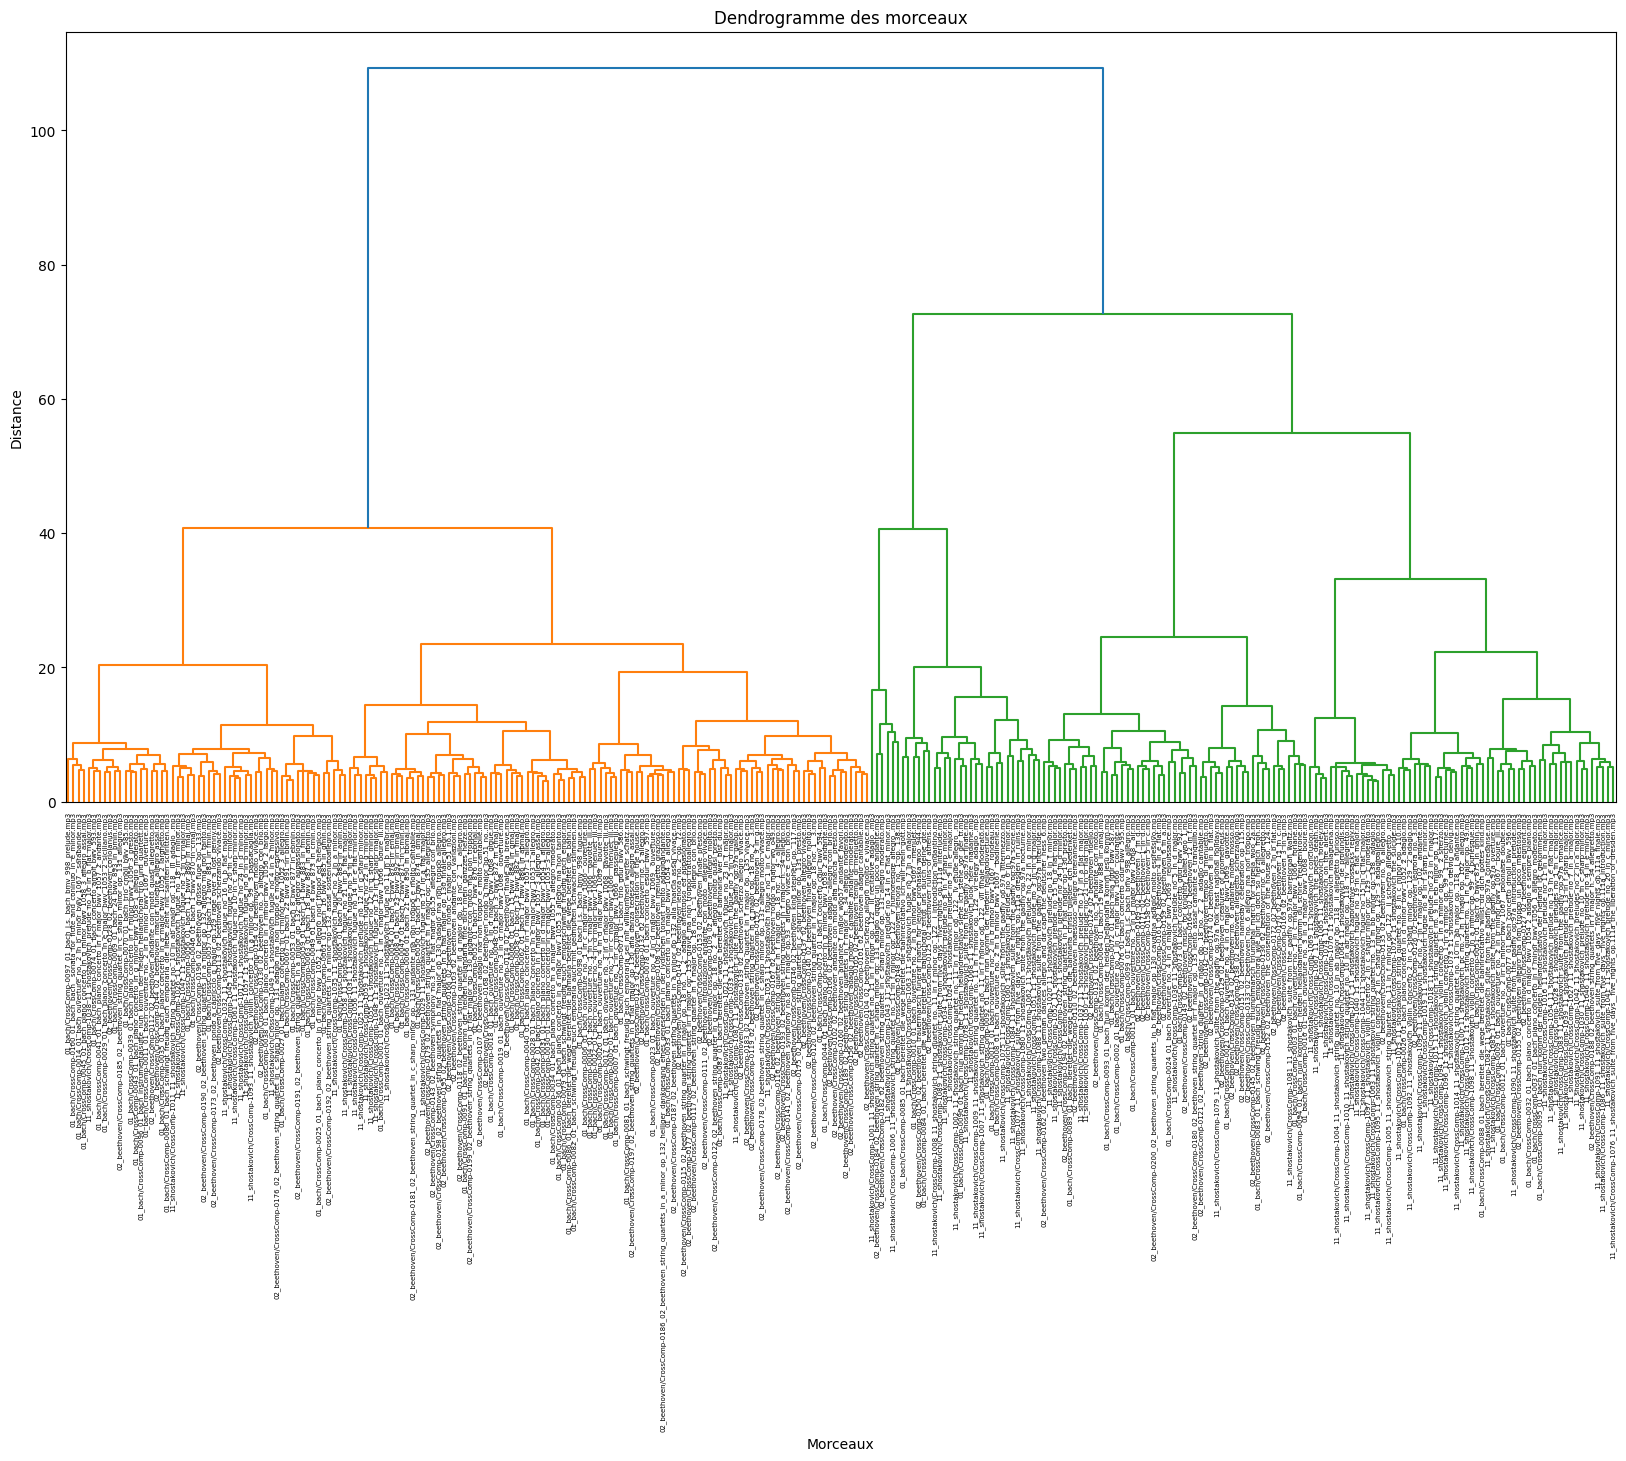

In [24]:
plot_dendrogram(dico, figs = (20, 10))

## Utilisation du DTW

In [25]:
def distance_matrix_dtw(dico):
    clefs = list(dico.keys())
    items = list(dico.values())
    mat = np.zeros((len(clefs), len(clefs)))
    for i in range(len(clefs)):
        for j in range(len(clefs)):
            D, wp = librosa.sequence.dtw(items[i],items[j])
            mat[i][j] = D[-1,-1]
    return clefs,mat

In [26]:
def plot_dendrogram_dtw(dico, figs = (10, 7)):
    titres,mat = distance_matrix_dtw(dico)
    Z = linkage(mat, 'ward')
    plt.figure(figsize=figs)
    dendrogram(Z, labels=titres, leaf_rotation=90)
    plt.title('Dendrogramme des morceaux')
    plt.xlabel('Morceaux')
    plt.ylabel('Distance')
    plt.show()

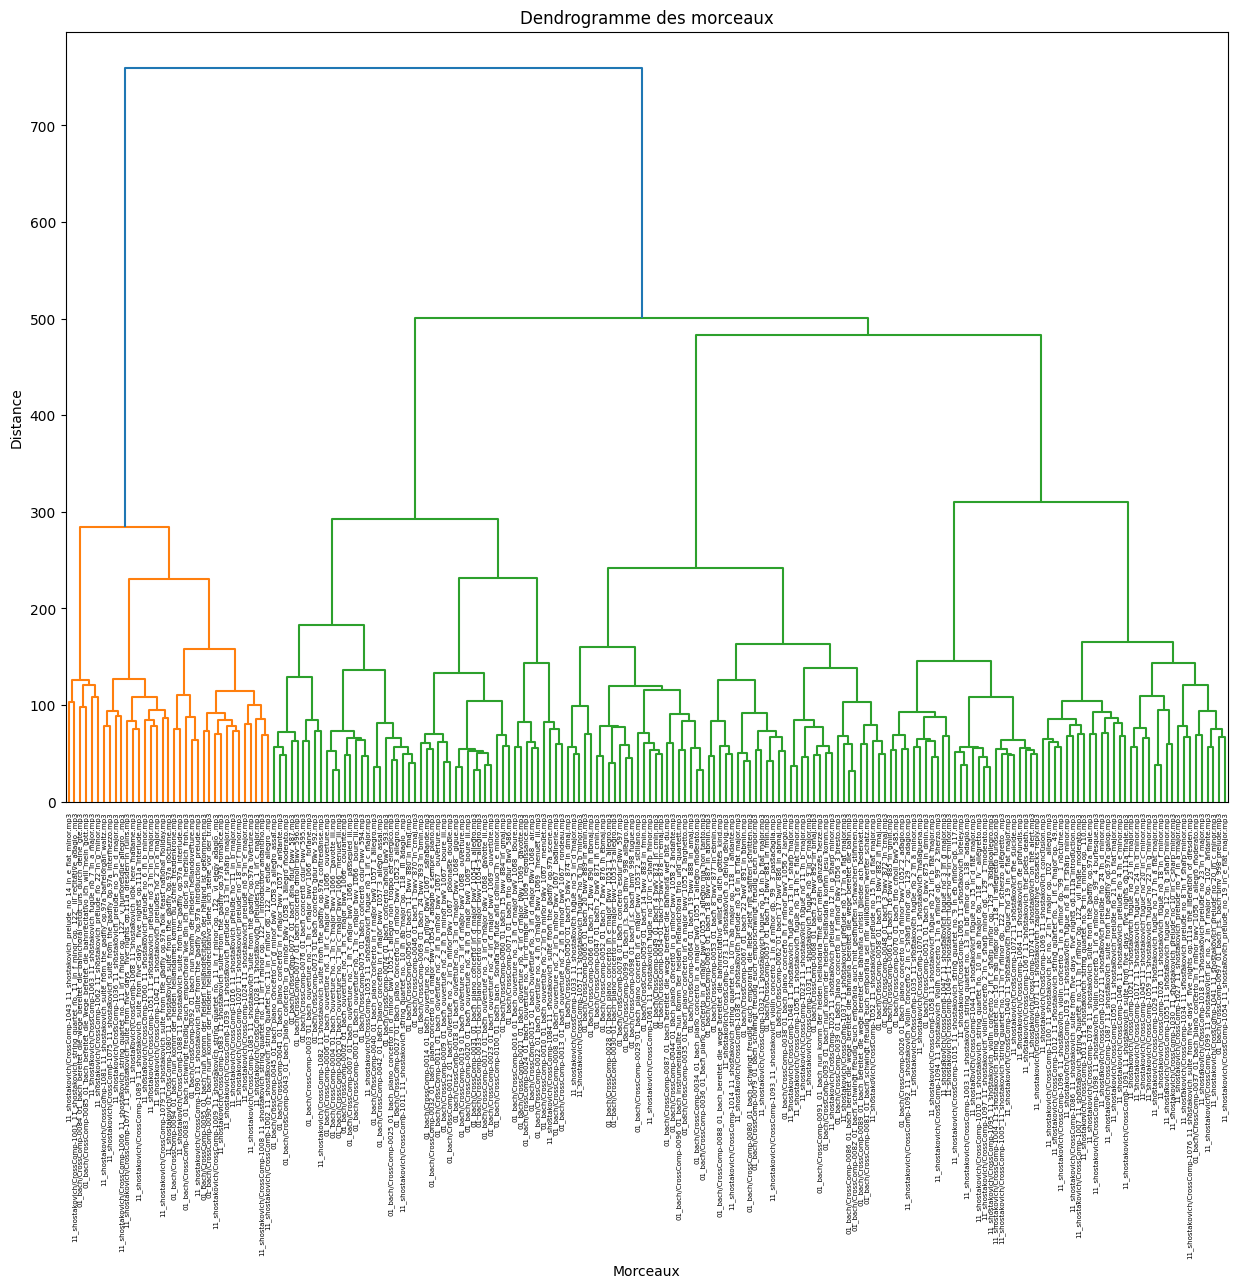

In [ ]:
plot_dendrogram_dtw(dico,figs = (20, 10))